In [1]:
!pip install -q -U watermark

In [31]:
# Importação da biblioteca para Manipulação de dados em tabelas
import pandas as pd 

# Importação da biblioteca NumPy para operações matemáticas e arrays
import numpy as np 

# Importação da biblioteca Matplotlib para geração de gráficos
import matplotlib.pyplot as plt 

# Importação da biblioteca Seaborn para visualização estátistica de dados
import seaborn as sns 

# Importação da biblioteca random para geração de números aleatorios
import random 

#Importação das classes datetime e timedelta para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta 

# Comando do jupyter que permite exibir gráficos diretamento no notebook
%matplotlib inline 

In [32]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [33]:
%watermark --iversion

matplotlib: 3.10.0
numpy     : 2.1.3
pandas    : 2.2.3
seaborn   : 0.13.2



# Função para geração de Dados

In [34]:
def gera_dados(num_registros = 600):
    ''' Gera um DataFrane do Pandas com dados de vendas '''

    print(f'Iniciando geração de {num_registros} registros de vendas...')

    # Dicionário com produto e suas categorias e preços
    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
    }

    # Cria uma lista apenas com os nomes do produtos
    lista_produtos = list(produtos.keys())

    # Dicionário com cidades e seus estados
    cidades_estados = {
        'São Paulo': 'SP', 'Rio de Janeiro': 'RJ', 'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 'Salvador': 'BA', 'Curitiba': 'PR', 'Fortaleza': 'CE'
    }

    # Cria uma lista apenas com os nomes das cidades
    lista_cidades = list(cidades_estados.keys())

    # Lista que armazenara os registros de vendas
    dados_vendas = []

    # Define a data inicial dos pedidos
    data_inicial = datetime(2026, 1, 1)

    # Loop para gerar os registros de vendas
    for i in range(num_registros):

        # Seleciona aleatoriamente um produto
        produto_nome = random.choice(lista_produtos)

        # Seleciona aleatoriamente uma cidade
        cidade = random.choice(lista_cidades)

        # Gera a quantidade de produtos vendida entre 1 e 7
        quantidade = np.random.randint(1, 8)

        # Calcula a data do pedido a partir do pedido inicial
        data_pedido = data_inicial + timedelta(days = int(i/5), hours = random.randint(0, 23))

        # Se o produto for Mouse ou Teclado aplica desconto aleatório de até 10%
        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[produto_nome]['preco']


        # Adiciona um registro de venda à lista
        dados_vendas.append({
            'ID_Pedido': 1000 + i,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': np.random.randint(100,150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]
        })


    # Finish
    print('Geração de dados concluida\n\n')
    return pd.DataFrame(dados_vendas)

# Gerar, Carregar e Explorar os Dados

In [35]:
df_vendas = gera_dados(500)

Iniciando geração de 500 registros de vendas...
Geração de dados concluida




In [36]:
# Shape
df_vendas.shape

(500, 9)

In [37]:
# Exibe as 5 primeiras linhas do DataFrame
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 13:00:00,Placa de Vídeo,Hardware,4500.00,1,149,Belo Horizonte,MG
1,1001,2026-01-01 16:00:00,Headset 7.1,Acessórios,800.00,7,112,Salvador,BA
2,1002,2026-01-01 14:00:00,Mouse Vertical,Acessórios,244.63,5,140,Curitiba,PR
3,1003,2026-01-01 16:00:00,Mouse Vertical,Acessórios,226.43,4,125,Porto Alegre,RS
4,1004,2026-01-01 05:00:00,Laptop Gamer,Eletrônicos,7500.00,4,134,Belo Horizonte,MG


In [38]:
# Exibe as 5 ultimas linhas do DataFrame
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
495,1495,2026-04-10 23:00:00,Mouse Vertical,Acessórios,235.94,6,140,Curitiba,PR
496,1496,2026-04-10 18:00:00,Placa de Vídeo,Hardware,4500.00,4,146,São Paulo,SP
497,1497,2026-04-10 07:00:00,Placa de Vídeo,Hardware,4500.00,1,145,Porto Alegre,RS
498,1498,2026-04-10 05:00:00,Cadeira Gamer,Móveis,1200.00,6,140,Curitiba,PR
499,1499,2026-04-10 13:00:00,Laptop Gamer,Eletrônicos,7500.00,6,105,São Paulo,SP


In [39]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 35.3+ KB


In [40]:
# Resumo estatístico
df_vendas.describe()

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.000000,500.000000,500.000000
mean,1249.500000,2026-02-19 22:50:24,2302.837000,3.972000,124.386000
min,1000.000000,2026-01-01 05:00:00,225.520000,1.000000,100.000000
25%,1124.750000,2026-01-26 03:00:00,547.505000,2.000000,111.000000
50%,1249.500000,2026-02-20 00:30:00,1200.000000,4.000000,124.500000
75%,1374.250000,2026-03-16 22:45:00,4500.000000,6.000000,137.000000
max,1499.000000,2026-04-10 23:00:00,7500.000000,7.000000,149.000000
std,144.481833,NaN,2406.599435,2.032604,14.576761


In [41]:
# Tipos de dados
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
dtype: object

# Limpeza, Pré-Processamento e Engenharia de Atributos

In [42]:
# Se a coluna 'Data_Pedido' não estiver como tipo datetime, precisamos fazer a conversão explícita
# A coluna pode ser usada para análise temporal
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [43]:
# Engenharia de atributos
# Criando a coluna 'Faturamento' (preço x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [44]:
# Engenharia de atributos
# Usando uma função lambda para criar uma coluna de status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápida' if estado in ['SP', 'RJ','MG'] else 'Normal')

In [45]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[ns]
 2   Nome_Produto    500 non-null    object        
 3   Categoria       500 non-null    object        
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    object        
 8   Estado          500 non-null    object        
 9   Faturamento     500 non-null    float64       
 10  Status_Entrega  500 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 43.1+ KB


In [46]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 13:00:00,Placa de Vídeo,Hardware,4500.00,1,149,Belo Horizonte,MG,4500.00,Rápida
1,1001,2026-01-01 16:00:00,Headset 7.1,Acessórios,800.00,7,112,Salvador,BA,5600.00,Normal
2,1002,2026-01-01 14:00:00,Mouse Vertical,Acessórios,244.63,5,140,Curitiba,PR,1223.15,Normal
3,1003,2026-01-01 16:00:00,Mouse Vertical,Acessórios,226.43,4,125,Porto Alegre,RS,905.72,Normal
4,1004,2026-01-01 05:00:00,Laptop Gamer,Eletrônicos,7500.00,4,134,Belo Horizonte,MG,30000.00,Rápida


# Analise 1 - Top 10 Produtos mais Vendidos

In [47]:
# Agrupa por nome do produto, soma a quantidade e ordena para encontrar os mais vendidos
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [48]:
top_10_produtos

Nome_Produto
Cadeira Gamer        318
Teclado Mecânico     283
Mouse Vertical       267
Laptop Gamer         257
Placa de Vídeo       251
Headset 7.1          242
Monitor Ultrawide    216
SSD 1TB              152
Name: Quantidade, dtype: int64

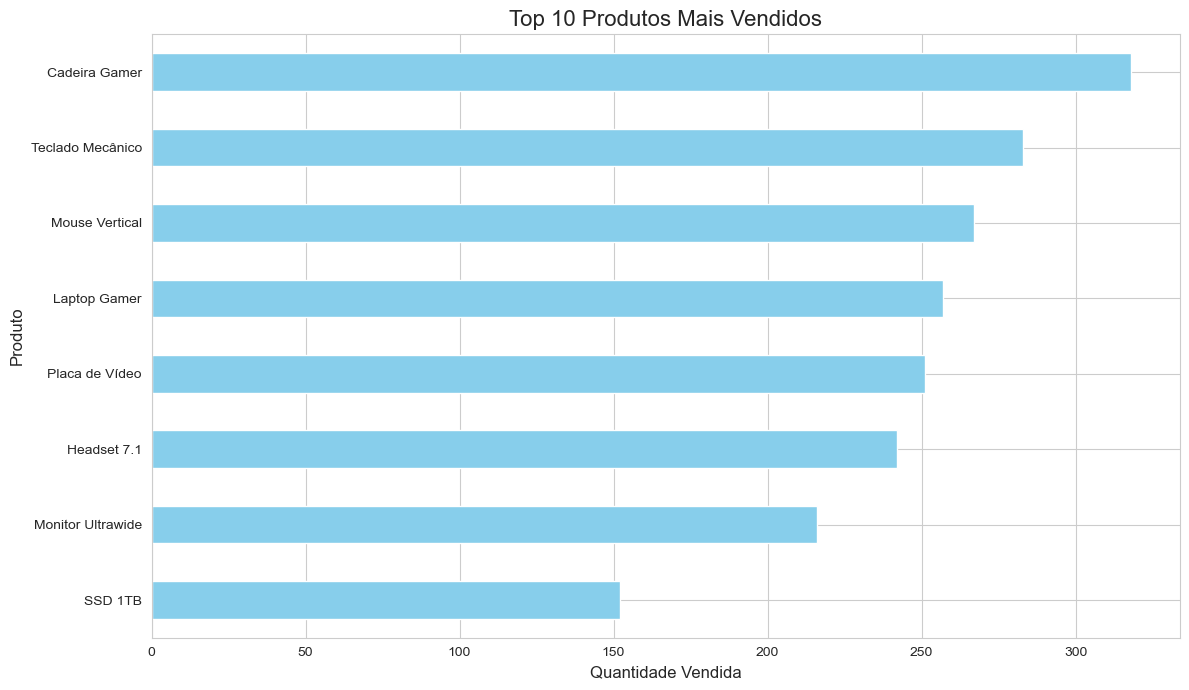

In [49]:
# Define um estilo para os gráficos
sns.set_style('whitegrid')

# Cria a figura e os eixos
plt.figure(figsize = (12, 7))

# Cria o gráfico de barras horizontais
top_10_produtos.sort_values(ascending = True).plot(kind = 'barh', color = 'skyblue')

# Adiciona títulos e labels
plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.xlabel('Quantidade Vendida', fontsize = 12)
plt.ylabel('Produto', fontsize = 12)

# Exibe o gráfico
plt.tight_layout()
plt.show()

# Analise 2 - Faturamento Mensal

In [50]:

df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [51]:
df_vendas.head(5)

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 13:00:00,Placa de Vídeo,Hardware,4500.00,1,149,Belo Horizonte,MG,4500.00,Rápida,2026-01
1,1001,2026-01-01 16:00:00,Headset 7.1,Acessórios,800.00,7,112,Salvador,BA,5600.00,Normal,2026-01
2,1002,2026-01-01 14:00:00,Mouse Vertical,Acessórios,244.63,5,140,Curitiba,PR,1223.15,Normal,2026-01
3,1003,2026-01-01 16:00:00,Mouse Vertical,Acessórios,226.43,4,125,Porto Alegre,RS,905.72,Normal,2026-01
4,1004,2026-01-01 05:00:00,Laptop Gamer,Eletrônicos,7500.00,4,134,Belo Horizonte,MG,30000.00,Rápida,2026-01


In [52]:
# Agrupa por mês e soma o faturamento
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [53]:
# Converte o índice para string para facilitar a plotagem no gráfico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [54]:
# Formata para duas caddas decimais 
faturamento_mensal.map('R$ {:,.2f}'.format)

Mes
2026-01    R$ 1,455,793.50
2026-02    R$ 1,232,770.68
2026-03    R$ 1,383,354.17
2026-04      R$ 468,589.10
Name: Faturamento, dtype: object

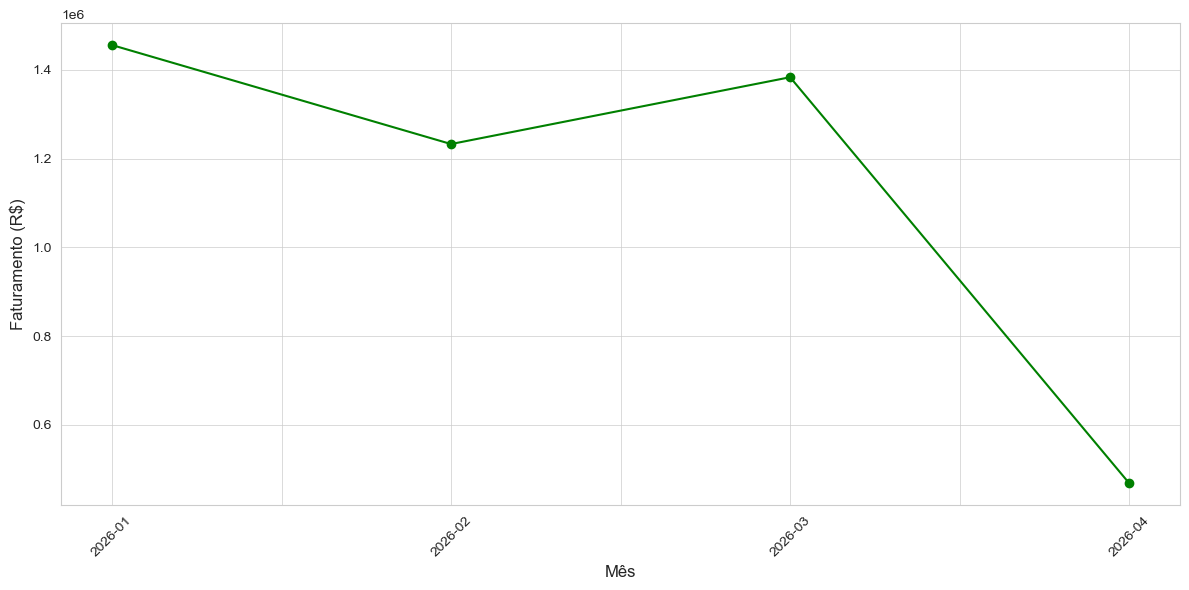

In [55]:
# Cria uma nova figura com tamanho de 12 por 6 polegadas
plt.figure(figsize = (12, 6))

# Plota os dados de faturamento mensal em formato de linha
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')

# Define o rótulo do eixo X
plt.xlabel('Mês', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Rotaciona os valores do eixo X em 45 graus para melhorar visualização
plt.xticks(rotation = 45)

# Adiciona uma grade com estilo tracejado e linhas finas
plt.grid(True, which = 'both', linestyle = "-", linewidth = 0.5)

# Ajusta automaticamente os elementos para evitar sobreposição 
plt.tight_layout()

# Exibe o gráfico
plt.show()

# Análise 3 - Vendas Por Estado

In [56]:
# Agrupa por estado e soma o faturamento
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False)

In [57]:
vendas_estado.map('R$ {:,.2f}'.format)

Estado
SP    R$ 790,226.71
CE    R$ 770,041.28
BA    R$ 760,654.30
PR    R$ 662,857.11
MG    R$ 582,084.74
RS    R$ 496,944.12
RJ    R$ 477,699.19
Name: Faturamento, dtype: object

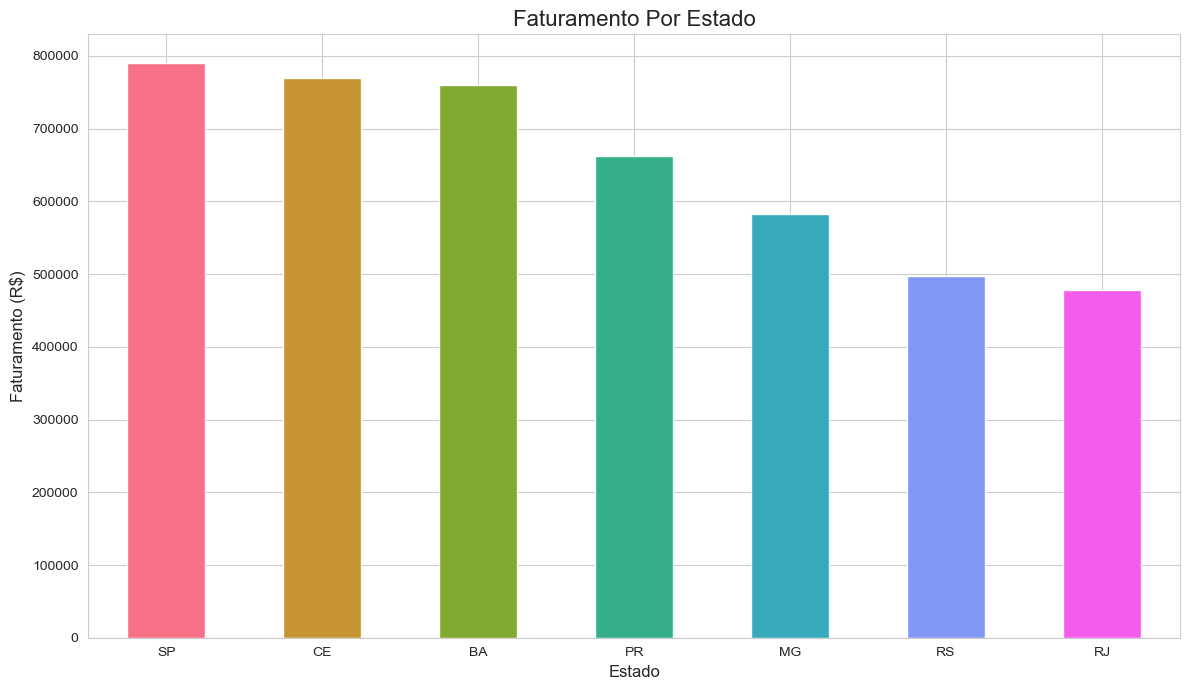

In [58]:
# Cria uma nova figura com tamanho de 12 por 7 polegadas
plt.figure(figsize = (12, 7))

# Plota os dados de faturamento por estado em formato de gráfico de barras
# Usando a paleta de cores "rocket" do Seaborn
vendas_estado.plot(kind = 'bar', color = sns.color_palette("husl", 7))

# Define o título do gráfico com fonte de tamanho 16
plt.title('Faturamento Por Estado', fontsize = 16)

# Define o rótulo do eixo X
plt.xlabel('Estado', fontsize = 12)

# Define o rótulo do eixo Y
plt.ylabel('Faturamento (R$)', fontsize = 12)

# Mantém os rótulos do eixo X na horizontal (sem rotação)
plt.xticks(rotation = 0)

# Ajusta automaticamente os elementos do gráfico para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

# Analise 4 - Faturamento Por Categoria

In [60]:
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

In [61]:
# O .map('{:,.2f)'}.format) é opcional, mas deixa a visualização mais clara
faturamento_categoria.map('R$ {:,.2f}'.format)

Categoria
Eletrônicos    R$ 2,532,300.00
Hardware       R$ 1,220,700.00
Acessórios       R$ 405,907.45
Móveis           R$ 381,600.00
Name: Faturamento, dtype: object

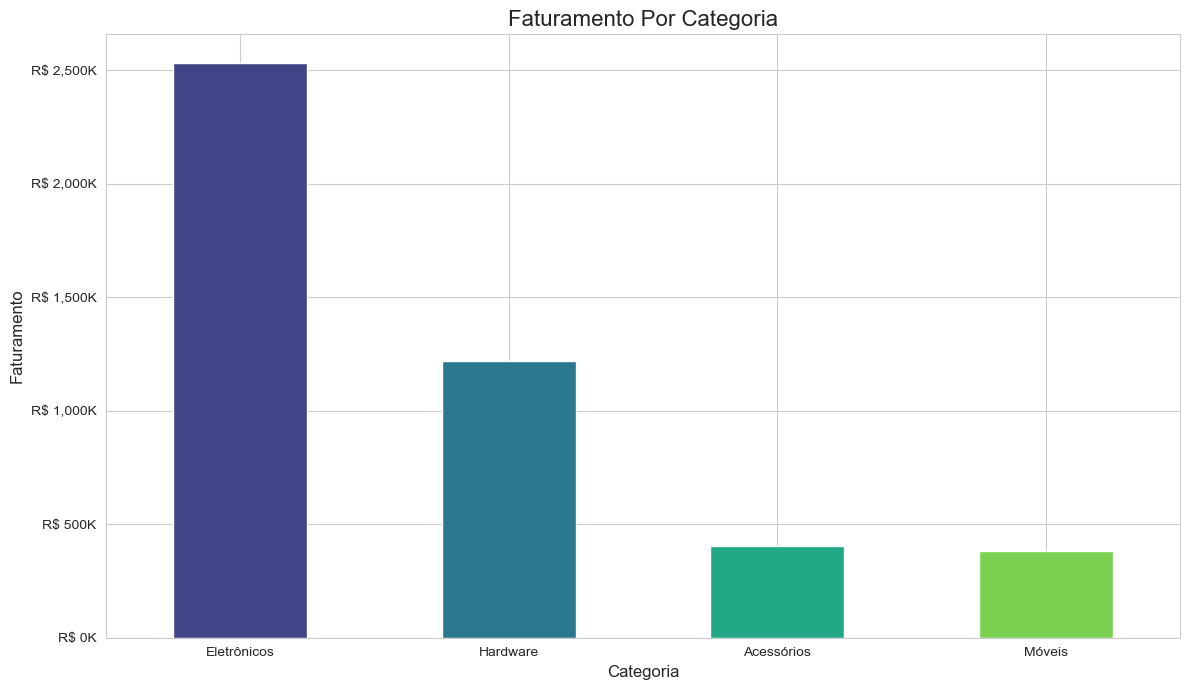

In [75]:
# Importa a função FuncFormatter para formar eixos
from matplotlib.ticker import FuncFormatter

# Ordena os dados para gráfico ficar mais fácil de ler
faturamento_ordenado = faturamento_categoria.sort_values(ascending = False)

# Cria Figura e os Eixos (ax) com plt.subplots()
# Isso nos dá mais controle sobre os elementos do gráfico.
fig, ax = plt.subplots(figsize = (12, 7))

# Cria uma função para formatar os números
# Esta função recebe um valor 'y' e o transforma em uma string no formato 'R$ XX K'
def formatador_milhares(y, poss):
    '''Formata o valor em milhares (K) com cifrão R$'''
    return f'R$ {y/1000:,.0f}K'

# Cria o objeto formatador
formatter = FuncFormatter(formatador_milhares)

# Aplica o formatador ao eixo Y (ax,yaxis)
ax.yaxis.set_major_formatter(formatter)

# Plota os dados usando o objeto 'ax'
faturamento_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette('viridis', len(faturamento_ordenado)))

# Adiciona títulos e labels usando 'ax.set_...'
ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)

# Ajusta a rotação do eixo X
plt.xticks(rotation = 0, ha = 'center')

# Garante que tudo fique bem ajustado na imagem final
plt.tight_layout()

# Exibe o Gráfico
plt.show()